In [13]:
%pip install --quiet tensorflow scikit-learn matplotlib optuna

Note: you may need to restart the kernel to use updated packages.


# GRU sur UCI HAR

Ce notebook implémente un pipeline complet de classification d'activités humaines à partir des signaux inertiels du dataset UCI HAR.

Le flux suit l'esprit du notebook 089: chargement des données, prétraitement, recherche d'hyperparamètres légère avec Optuna, entraînement final, puis évaluation et visualisations.

In [14]:
from pathlib import Path
import tempfile
import urllib.request
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

import optuna

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

DATA_DIR = Path(r"D:\100DaysofML\Notebooks\090_GRU\UCI HAR Dataset")

ACTIVITY_NAMES = [
    'WALKING',
    'WALKING_UPSTAIRS',
    'WALKING_DOWNSTAIRS',
    'SITTING',
    'STANDING',
    'LAYING',
]

SIGNAL_NAMES = [
    'body_acc_x',
    'body_acc_y',
    'body_acc_z',
    'body_gyro_x',
    'body_gyro_y',
    'body_gyro_z',
    'total_acc_x',
    'total_acc_y',
    'total_acc_z',
]

print(f'Data directory: {DATA_DIR}')
print(f'Activities: {ACTIVITY_NAMES}')

Data directory: D:\100DaysofML\Notebooks\090_GRU\UCI HAR Dataset
Activities: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']


In [15]:
def load_har_split(split_name):
    split_dir = DATA_DIR / split_name / 'Inertial Signals'
    signal_arrays = []

    for signal_name in SIGNAL_NAMES:
        file_path = split_dir / f'{signal_name}_{split_name}.txt'
        signal_arrays.append(np.loadtxt(file_path, dtype=np.float32))

    x = np.stack(signal_arrays, axis=-1).astype(np.float32)
    y = np.loadtxt(DATA_DIR / split_name / f'y_{split_name}.txt', dtype=np.int32) - 1
    subjects = np.loadtxt(DATA_DIR / split_name / f'subject_{split_name}.txt', dtype=np.int32)
    return x, y, subjects

X_train_full, y_train_full, subject_train_full = load_har_split('train')
X_test, y_test, subject_test = load_har_split('test')

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train_full,
)

feature_mean = X_train.mean(axis=(0, 1), keepdims=True)
feature_std = X_train.std(axis=(0, 1), keepdims=True) + 1e-6

X_train = (X_train - feature_mean) / feature_std
X_val = (X_val - feature_mean) / feature_std
X_test = (X_test - feature_mean) / feature_std

print('Train shape:', X_train.shape, y_train.shape)
print('Val shape:', X_val.shape, y_val.shape)
print('Test shape:', X_test.shape, y_test.shape)
print('Number of classes:', len(ACTIVITY_NAMES))

Train shape: (6249, 128, 9) (6249,)
Val shape: (1103, 128, 9) (1103,)
Test shape: (2947, 128, 9) (2947,)
Number of classes: 6


In [16]:
def build_gru_model(units_1=128, units_2=64, dense_units=64, dropout=0.3, learning_rate=1e-3):
    inputs = keras.Input(shape=X_train.shape[1:])
    x = layers.GRU(units_1, return_sequences=True, dropout=dropout)(inputs)
    x = layers.GRU(units_2, dropout=dropout)(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(len(ACTIVITY_NAMES), activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='gru_har')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model


In [17]:
# Optuna quick search + final training and evaluation
import optuna

USE_OPTUNA = True
N_TRIALS = 3
OPTUNA_EPOCHS = 3

print('Running quick Optuna search with', N_TRIALS, 'trials and', OPTUNA_EPOCHS, 'epochs/trial')

def objective_quick(trial):
    units_1 = trial.suggest_categorical('units_1', [64, 96, 128])
    units_2 = trial.suggest_categorical('units_2', [32, 64])
    dense_units = trial.suggest_categorical('dense_units', [32, 64])
    dropout = trial.suggest_float('dropout', 0.15, 0.4)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 3e-3, log=True)

    model = build_gru_model(
        units_1=units_1,
        units_2=units_2,
        dense_units=dense_units,
        dropout=dropout,
        learning_rate=learning_rate,
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=OPTUNA_EPOCHS,
        batch_size=128,
        verbose=0,
    )

    return max(history.history.get('val_accuracy', [0]))

if USE_OPTUNA:
    study = optuna.create_study(direction='maximize')
    study.optimize(objective_quick, n_trials=N_TRIALS)
    best_params = study.best_params
else:
    best_params = {
        'units_1': 128,
        'units_2': 64,
        'dense_units': 64,
        'dropout': 0.3,
        'learning_rate': 1e-3,
    }

print('Best params:', best_params)

[I 2026-05-18 12:54:51,300] A new study created in memory with name: no-name-eab930ed-2028-4119-a994-8b0512291ebe


Running quick Optuna search with 3 trials and 3 epochs/trial


[I 2026-05-18 12:55:47,906] Trial 0 finished with value: 0.5766092538833618 and parameters: {'units_1': 64, 'units_2': 64, 'dense_units': 32, 'dropout': 0.3126006919669871, 'learning_rate': 0.0001762877234802261}. Best is trial 0 with value: 0.5766092538833618.
[I 2026-05-18 12:57:16,292] Trial 1 finished with value: 0.4895738959312439 and parameters: {'units_1': 128, 'units_2': 64, 'dense_units': 32, 'dropout': 0.3716263285145429, 'learning_rate': 0.00013093442296004996}. Best is trial 0 with value: 0.5766092538833618.
[I 2026-05-18 12:58:02,880] Trial 2 finished with value: 0.5947416424751282 and parameters: {'units_1': 64, 'units_2': 32, 'dense_units': 64, 'dropout': 0.3806806321881316, 'learning_rate': 0.0003824873201793524}. Best is trial 2 with value: 0.5947416424751282.


Best params: {'units_1': 64, 'units_2': 32, 'dense_units': 64, 'dropout': 0.3806806321881316, 'learning_rate': 0.0003824873201793524}


In [18]:

# Build final model and train
final_model = build_gru_model(**best_params)

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5),
]

history = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=128,
    verbose=1,
    callbacks=callbacks,
)

Epoch 1/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 22s 291ms/step - accuracy: 0.3383 - loss: 1.6332 - val_accuracy: 0.4651 - val_loss: 1.3755 - learning_rate: 3.8249e-04
Epoch 2/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 13s 262ms/step - accuracy: 0.4431 - loss: 1.3807 - val_accuracy: 0.4832 - val_loss: 1.2197 - learning_rate: 3.8249e-04
Epoch 3/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 13s 263ms/step - accuracy: 0.4873 - loss: 1.2773 - val_accuracy: 0.6047 - val_loss: 1.0638 - learning_rate: 3.8249e-04
Epoch 4/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 13s 257ms/step - accuracy: 0.5326 - loss: 1.1366 - val_accuracy: 0.6709 - val_loss: 0.8582 - learning_rate: 3.8249e-04
Epoch 5/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 20s 251ms/step - accuracy: 0.5721 - loss: 0.9932 - val_accuracy: 0.7380 - val_loss: 0.6742 - learning_rate: 3.8249e-04
Epoch 6/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 13s 256ms/step - accuracy: 0.5956 - loss: 0.8841 - val_accuracy: 0.7362 - val_loss: 0.6429 - learning_rate: 3.8249e-04
Epoch 7/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 13s 256ms/step - acc

In [19]:



# Evaluation
train_loss, train_accuracy = final_model.evaluate(X_train, y_train, verbose=0)
val_loss, val_accuracy = final_model.evaluate(X_val, y_val, verbose=0)
test_loss, test_accuracy = final_model.evaluate(X_test, y_test, verbose=0)

print(f'Train loss: {train_loss:.4f}, Train accuracy: {train_accuracy:.4f}')
print(f'Val loss:   {val_loss:.4f}, Val accuracy:   {val_accuracy:.4f}')
print(f'Test loss:  {test_loss:.4f}, Test accuracy:  {test_accuracy:.4f}')

y_prob = final_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=ACTIVITY_NAMES))

Train loss: 0.2822, Train accuracy: 0.9086
Val loss:   0.2837, Val accuracy:   0.9084
Test loss:  0.3733, Test accuracy:  0.8649

Classification report:
                    precision    recall  f1-score   support

           WALKING       0.82      0.88      0.85       496
  WALKING_UPSTAIRS       0.87      0.84      0.85       471
WALKING_DOWNSTAIRS       0.98      0.88      0.93       420
           SITTING       0.92      0.62      0.74       491
          STANDING       0.71      0.95      0.81       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.86      2947
         macro avg       0.88      0.86      0.86      2947
      weighted avg       0.88      0.86      0.86      2947



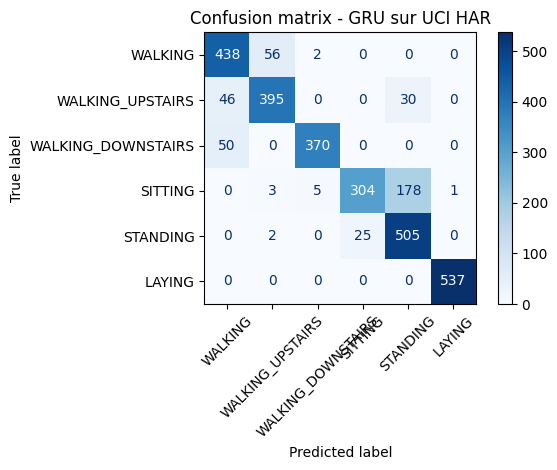

In [20]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ACTIVITY_NAMES)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion matrix - GRU sur UCI HAR')
plt.tight_layout()
plt.show()


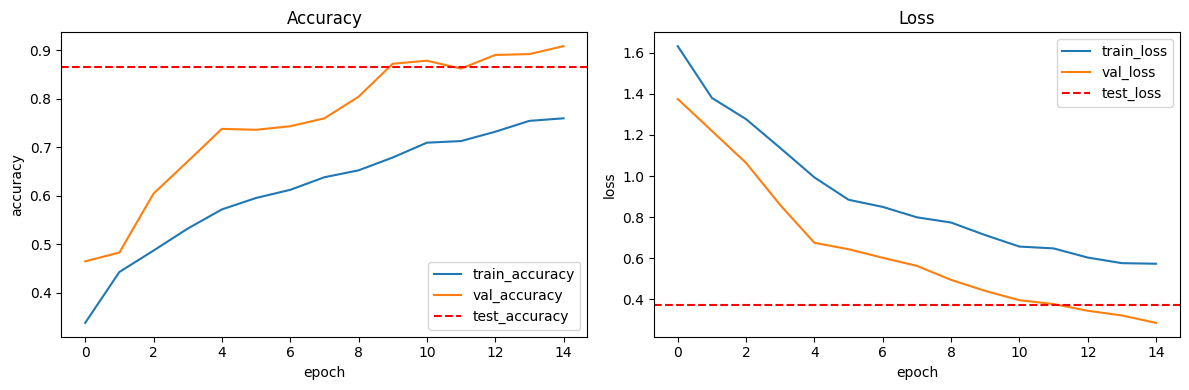

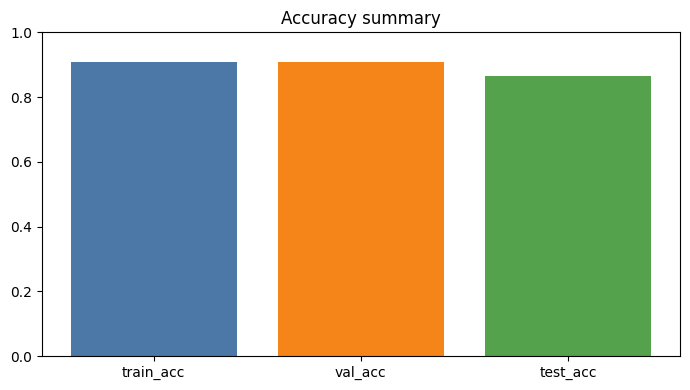

In [22]:

# Training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history.get('accuracy', []), label='train_accuracy')
plt.plot(history.history.get('val_accuracy', []), label='val_accuracy')
plt.axhline(test_accuracy, color='red', linestyle='--', label='test_accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history.get('loss', []), label='train_loss')
plt.plot(history.history.get('val_loss', []), label='val_loss')
plt.axhline(test_loss, color='red', linestyle='--', label='test_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Compact metric summary
plt.figure(figsize=(7, 4))
labels = ['train_acc', 'val_acc', 'test_acc']
values = [train_accuracy, val_accuracy, test_accuracy]
plt.bar(labels, values, color=['#4c78a8', '#f58518', '#54a24b'])
plt.ylim(0, 1)
plt.title('Accuracy summary')
plt.tight_layout()
plt.show()